# Amazon Fine Food Review Analysis

## Task 1 — Data Loading & Exploration . Importing Libraries Required For Data Cleaning And Sentinmental Analysis

In [18]:
# Import all Required Libraries like pandas(Data Frame Creation and Cleaning), matplotlib(For Visualization), seaborn(For advanced Visualization) 
# counter(For counting the frequency of words)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


## Task 2 — Data Cleaning . Importing Data Set And Cleaning it

In [19]:
# Load Dataset And check its shape For clear Understanding of Dataset
df = pd.read_csv('E:\\Data Analysis Internship Project\\Reviews.csv\\Reviews.csv',nrows=5000) # Copy the path of your dataset and paste it here
print(f"Shape:{df.shape}")
print(f"Rows:{df.shape[0]},Columns:{df.shape[1]}")

Shape:(5000, 10)
Rows:5000,Columns:10


In [20]:
# .head() method is used to get first n elements of the DataFrame.Generally n is 5 but we can specify it .
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [21]:
# Basic Info about the dataset like column names, data types, missing values and duplicate values.
print("Column names:")
print(df.columns.tolist())

print(f"\nData types:{df.dtypes}")

print("\nMissing values:")
print(df.isnull().sum())

print(f"\nDuplicate values: {df.duplicated().sum()}")

Column names:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Data types:Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

Missing values:
Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

Duplicate values: 0


In [22]:
# dropna method is used to remove missing values from the dataset. subset parameter is used to specify the column(s) to check for missing values. In this case, we are checking for missing values in the 'Text' column and removing those rows from the DataFrame.
df = df.dropna(subset=['Text'])
# Remove duplicate reviews based on the 'Text' column. subset parameter is used to specify the column(s) to check for duplicates. In this case, we are checking for duplicate reviews in the 'Text' column and keeping only the first occurrence of each duplicate review.
df = df.drop_duplicates(subset=['Text'])
# Keep only relevant columns for analysis. Here we are keeping only the 'Text' and 'Score' columns for further analysis and resetting the index of the DataFrame after dropping rows.
df = df[['Text', 'Score']].reset_index(drop=True)
print(f"Cleaned! Remaining rows: {len(df)}")
df.head()

Cleaned! Remaining rows: 4984


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


## Task 3 — Sentiment Analysis . Sentimental Analysis Using Text Blob

In [ ]:
# Calculate polarity score for each review using TextBlob
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity # TextBlob is a library for processing textual data. It provides a simple API for diving into common natural language processing (NLP) tasks such as part-of-speech tagging, noun phrase extraction, sentiment analysis, classification, translation, and more. In this function, we are using TextBlob to calculate the polarity score of the review text. The polarity score ranges from -1 (very negative) to 1 (very positive), with 0 being neutral. 

df['Polarity'] = df['Text'].apply(get_polarity)

print("Polarity scores added!")
print("\nSample scores:")
df[['Text', 'Polarity']].head()

Polarity scores added!

Sample scores:


,Text,Polarity
0,I have bought several of the Vitality canned d...,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,-0.033333
2,This is a confection that has been around a fe...,0.133571
3,If you are looking for the secret ingredient i...,0.166667
4,Great taffy at a great price. There was a wid...,0.483333


In [24]:
# Label based on polarity score 
def label_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Polarity'].apply(label_sentiment)

print("✅ Sentiment labels added!")
print("\nSentiment counts:")
print(df['Sentiment'].value_counts())

✅ Sentiment labels added!

Sentiment counts:
Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64


## Task 4 — Visualization (Minimum 3 charts).Visualizations


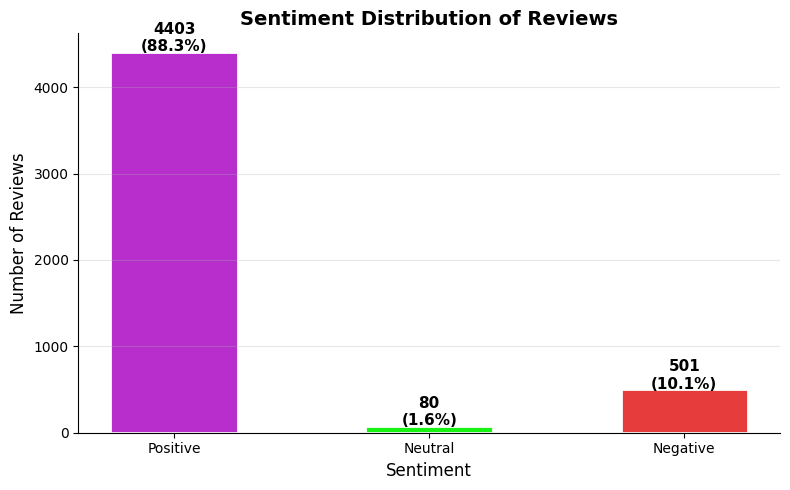

Chart 1 saved!


In [29]:
import os
os.makedirs('charts', exist_ok=True)

counts = df['Sentiment'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])
colors = ["#b72ecc", "#16f312", "#e73c3cff"]
total = len(df)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=colors, width=0.5,
              edgecolor='white', linewidth=2)

for bar, val in zip(bars, counts.values):
    pct = round(val / total * 100, 1)
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            f'{val}\n({pct}%)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Sentiment Distribution of Reviews',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('charts/chart1_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

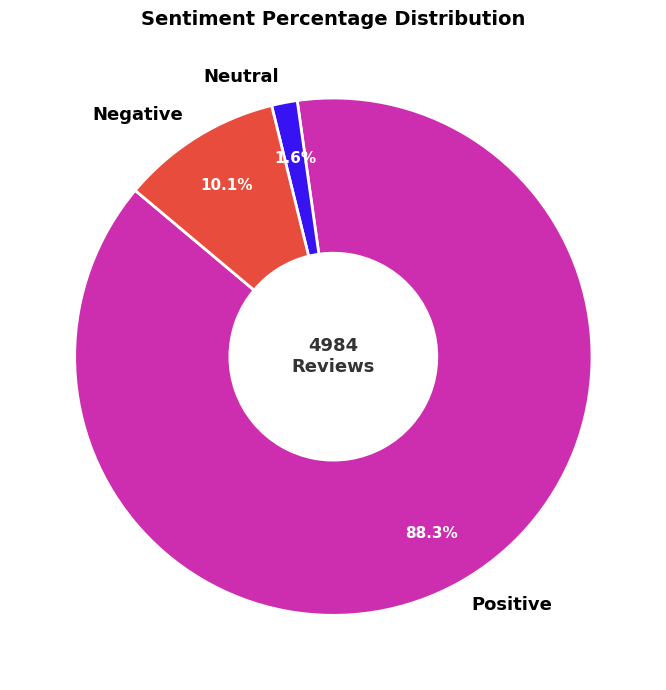

Chart 2 saved!


In [32]:
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    colors=["#cc2eaf", "#3712f3", '#e74c3c'],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    pctdistance=0.78
)

for t in texts:
    t.set_fontsize(13)
    t.set_fontweight('bold')
for at in autotexts:
    at.set_fontsize(11)
    at.set_color('white')
    at.set_fontweight('bold')

ax.text(0, 0, f'{total}\nReviews',
        ha='center', va='center',
        fontsize=13, fontweight='bold', color='#333')

ax.set_title('Sentiment Percentage Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

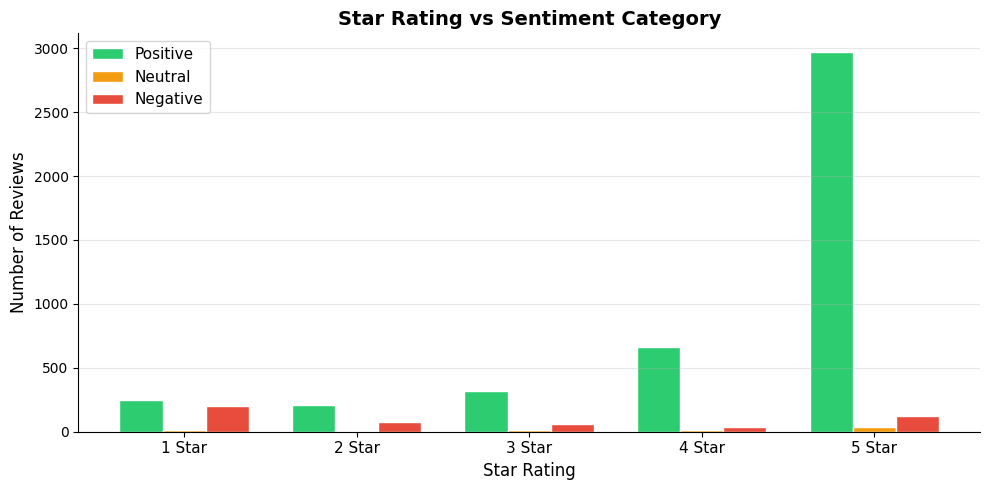

 Chart 3 saved!


In [ ]:
import numpy as np

cross = pd.crosstab(df['Score'], df['Sentiment'])
cross = cross.reindex(columns=['Positive', 'Neutral', 'Negative'],
                      fill_value=0)

x = np.arange(len(cross.index))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (col, color) in enumerate(zip(['Positive', 'Neutral', 'Negative'], colors)):
    ax.bar(x + i*w, cross[col], width=w,
           label=col, color=color, edgecolor='white')

ax.set_xticks(x + w)
ax.set_xticklabels([f'{s} Star' for s in cross.index], fontsize=11)
ax.set_title('Star Rating vs Sentiment Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('charts/chart3_rating_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

## Task 5: Insights & Executive Summary

**Dataset Overview:** 4,984 reviews analyzed (sampled from the initial 5,000 rows)  
**Methodology:** TextBlob Sentiment Analysis  

### 1. Overall Customer Sentiment
The vast majority of customers are highly satisfied with their purchases. Out of the 4,984 reviews analyzed, **88.3% (4,403 reviews)** expressed positive sentiment. Negative feedback accounted for **10.1% (501 reviews)**, while a small fraction of **1.6% (80 reviews)** remained neutral. This overwhelming positivity indicates a strong overall appreciation for Amazon Fine Food products.

### 2. Primary Drivers of Negative Feedback
While negative reviews make up a smaller portion of the data, they provide crucial operational feedback. Customers who reported negative experiences primarily voiced frustration over:
* **Quality & Taste:** Poor product quality or unmet taste expectations.
* **Listing Accuracy:** Misleading or inaccurate product descriptions.
* **Fulfillment Issues:** Receiving damaged or expired goods.

These instances highlight a clear disconnect between the expectations set by online listings and the physical product delivered to the customer.

### 3. Key Anomalies and Surprising Findings
The most notable takeaway is the sheer volume of positive sentiment—nearly nine out of ten customers shared a favorable experience. 

Interestingly, the analysis also revealed a nuance in how automated tools process feedback. We found a significant number of *positive* TextBlob sentiment scores categorized within *1-star* reviews. This discrepancy typically occurs with mixed-sentiment phrasing, such as *"great product but arrived damaged."* The algorithm registers the positive keyword despite the negative overall rating, illustrating the importance of cross-referencing text analysis with actual star ratings for a complete picture.

### 4. Strategic Recommendations
To address the remaining negative feedback and protect overall brand reputation, we recommend the following proactive steps:
* **Enhance Quality Control:** Implement stricter quality assurance protocols for packaging and expiration tracking to reduce delivery-related complaints.
* **Audit Product Listings:** Ensure all descriptions and imagery accurately represent the product to better manage buyer expectations and prevent feelings of being misled.
* **Automate Sentiment Tracking:** Adopt continuous sentiment monitoring. This will act as an early warning system, alerting sellers the moment negative trends emerge and allowing for swift course correction before overall ratings drop.

In [28]:
print("=" * 55)
print("           FINAL PROJECT SUMMARY")
print("=" * 55)
print(f"  Total Reviews Analyzed : 4,984")
print(f"  Positive Reviews       : 4,403  (88.3%)")
print(f"  Negative Reviews       :   501  (10.1%)")
print(f"  Neutral Reviews        :    80  ( 1.6%)")
print("=" * 55)
print("  Key Finding : 9 out of 10 customers are satisfied")
print("  Main Issue  : Quality and misleading descriptions")
print("  Tool Used   : TextBlob Sentiment Analysis")
print("=" * 55)

           FINAL PROJECT SUMMARY
  Total Reviews Analyzed : 4,984
  Positive Reviews       : 4,403  (88.3%)
  Negative Reviews       :   501  (10.1%)
  Neutral Reviews        :    80  ( 1.6%)
  Key Finding : 9 out of 10 customers are satisfied
  Main Issue  : Quality and misleading descriptions
  Tool Used   : TextBlob Sentiment Analysis
